In [1]:
!pip install ultralytics opencv-python pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00


In [2]:
import os
import zipfile
import cv2
import pandas as pd

In [4]:
ZIP_PATH = "Table.v7-v7.yolov8.zip"
EXTRACT_PATH = "yolo_data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
image_dir = None
label_dir = None

for root, dirs, files in os.walk(EXTRACT_PATH):
    if "images" in root.lower():
        image_dir = root
    if "labels" in root.lower():
        label_dir = root

print("Images directory:", image_dir)
print("Labels directory:", label_dir)

Images directory: yolo_data/test/images
Labels directory: yolo_data/test/labels


In [6]:
def baseline_depth(box_height, img_height):
    return box_height / img_height

In [7]:
def improved_depth(box_height, box_bottom_y, img_height):
    size_score = box_height / img_height
    position_score = box_bottom_y / img_height

    # Adaptive weighting
    if size_score > 0.5:
        alpha, beta = 0.7, 0.3
    else:
        alpha, beta = 0.5, 0.5

    return alpha * size_score + beta * position_score


In [8]:
def depth_label(score):
    if score > 0.6:
        return "STOP"
    elif score > 0.35:
        return "CAUTION"
    else:
        return "SAFE"

In [9]:
results = []

images = [f for f in os.listdir(image_dir)
          if f.endswith((".jpg", ".png"))]

print("Total images:", len(images))

for img_name in images:
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(
        label_dir,
        img_name.replace(".jpg", ".txt").replace(".png", ".txt")
    )

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:
        cls, cx, cy, w, h = map(float, label.split())

        box_height = h * img_h
        box_bottom_y = (cy + h / 2) * img_h

        base = baseline_depth(box_height, img_h)
        improved = improved_depth(box_height, box_bottom_y, img_h)

        results.append({
            "Image": img_name,
            "Class_ID": int(cls),
            "Baseline_Depth": round(base, 3),
            "Improved_Depth": round(improved, 3),
            "Depth_Label": depth_label(improved)
        })

df = pd.DataFrame(results)
df.head()

Total images: 6


,Image,Class_ID,Baseline_Depth,Improved_Depth,Depth_Label
0,00052_jpg.rf.1fbeceefa21ee04f3b3fe1c786d3463d.jpg,4,0.465,0.731,STOP
1,00052_jpg.rf.1fbeceefa21ee04f3b3fe1c786d3463d.jpg,4,0.477,0.503,CAUTION
2,00006_jpg.rf.24f8f6f7e47e56af73dda09ee6756d28.jpg,4,0.717,0.750,STOP
3,013661c93e28e2d3_jpg.rf.9e683c935f43ff8dafe793...,6,0.999,0.999,STOP
4,01e26c519f755107_jpg.rf.c7fd19c324ab111ffb3f54...,6,0.999,0.999,STOP


In [10]:
df.to_csv("depth_navigation_results.csv", index=False)
print("Saved depth_navigation_results.csv")


Saved depth_navigation_results.csv


In [11]:
df[["Baseline_Depth", "Improved_Depth"]].describe()


,Baseline_Depth,Improved_Depth
count,7.000000,7.000000
mean,0.772143,0.824571
std,0.229715,0.179967
min,0.465000,0.503000
25%,0.597000,0.740500
50%,0.809000,0.841000
75%,0.969000,0.974000
max,0.999000,0.999000


In [12]:
df["Depth_Label"].value_counts()


,count
Depth_Label,
STOP,6
CAUTION,1


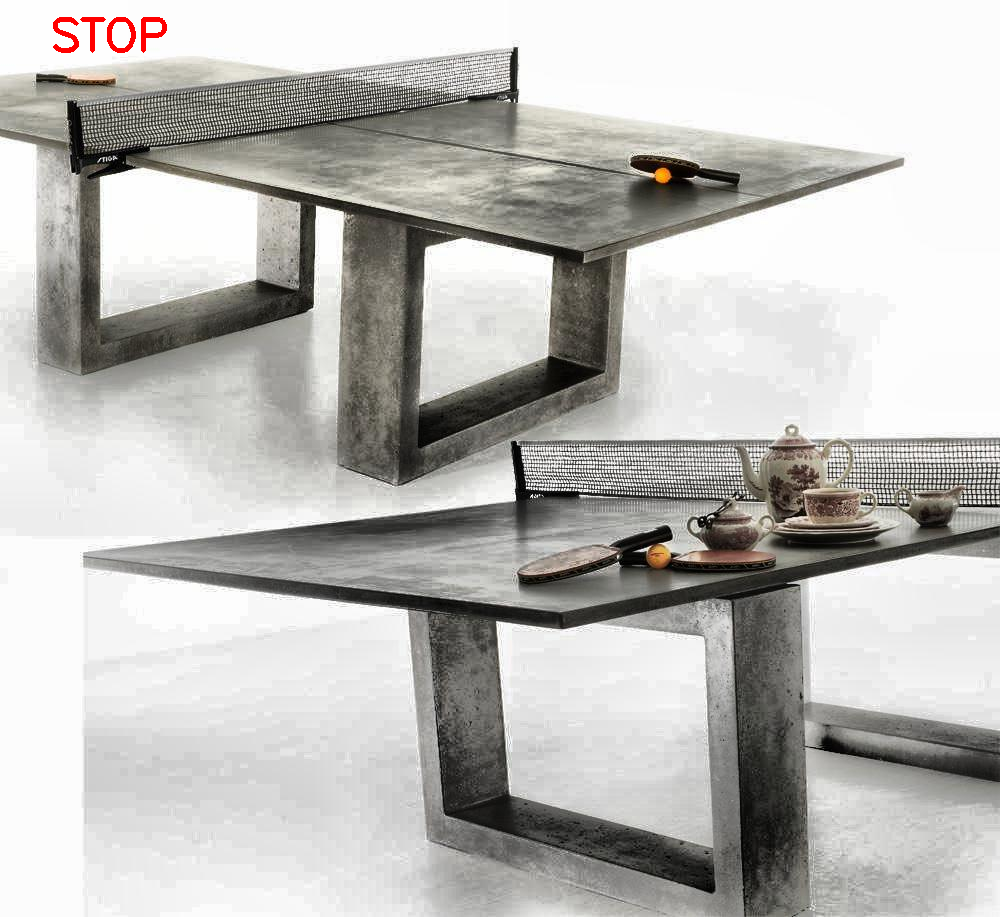

In [13]:
sample = df.iloc[0]
img = cv2.imread(os.path.join(image_dir, sample["Image"]))

cv2.putText(img, sample["Depth_Label"],
            (50, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1.5,
            (0, 0, 255), 3)

from google.colab.patches import cv2_imshow
cv2_imshow(img)


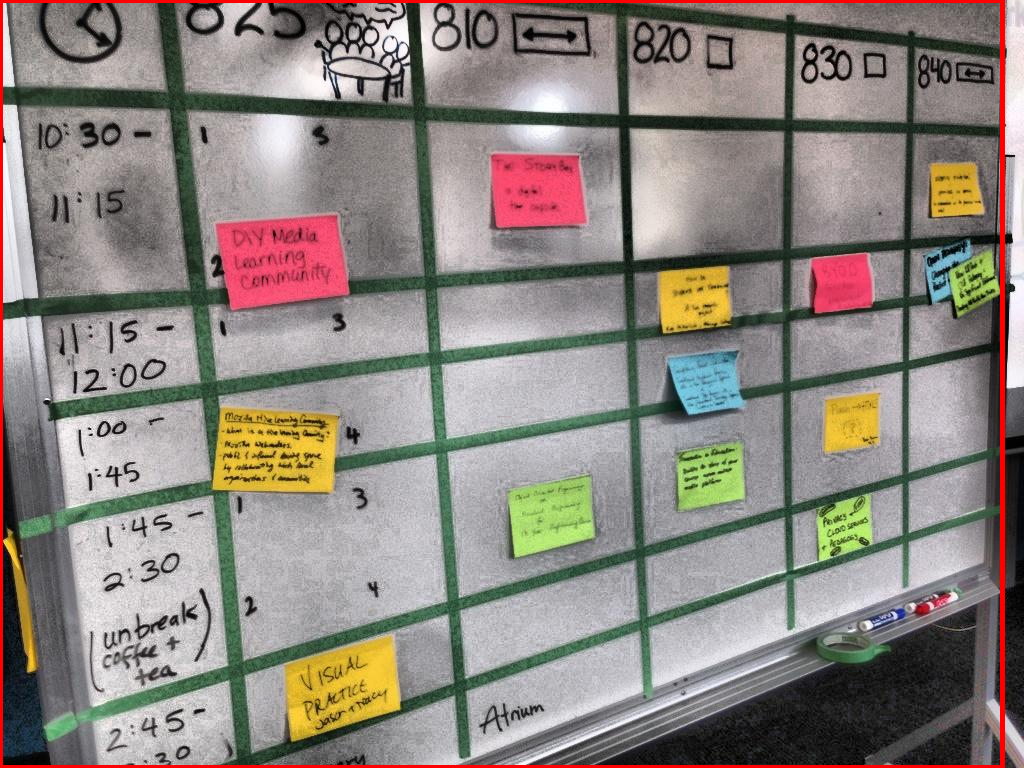

In [14]:
from google.colab.patches import cv2_imshow
import random

# Pick a random image
sample_img = random.choice(df["Image"].unique())

rows = df[df["Image"] == sample_img]

img = cv2.imread(os.path.join(image_dir, sample_img))
h, w = img.shape[:2]

# Load labels again to draw boxes
label_path = os.path.join(
    label_dir,
    sample_img.replace(".jpg", ".txt").replace(".png", ".txt")
)

with open(label_path, "r") as f:
    labels = f.readlines()

for i, label in enumerate(labels):
    cls, cx, cy, bw, bh = map(float, label.split())

    x1 = int((cx - bw/2) * w)
    y1 = int((cy - bh/2) * h)
    x2 = int((cx + bw/2) * w)
    y2 = int((cy + bh/2) * h)

    depth = rows.iloc[i]["Improved_Depth"]
    label_txt = rows.iloc[i]["Depth_Label"]

    color = (0,255,0)
    if label_txt == "STOP":
        color = (0,0,255)
    elif label_txt == "CAUTION":
        color = (0,255,255)

    cv2.rectangle(img, (x1,y1), (x2,y2), color, 3)
    cv2.putText(img, f"{label_txt} ({depth:.2f})",
                (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

cv2_imshow(img)
